<h1> DAY 2: Approximate Reinforcement Learning </h1>
<p> <img src="http://skyai.org/wiki/?plugin=attach&refer=Documentation%2FTutorial%20-%20Example%20-%20Mountain%20Car&openfile=mountaincar.png" alt="picture of the mountain-car environment" style="float:right;width:500px;border:10px solid #FFFFFF;">
<h3> MountainCar </h3>
<p> A car starts in a valley between two mountains, as depicted in the image to the right. The car must reach the goal location on the top of the right mountain by using three possible actions: accelerate forwards, backwards or doing nothing. However, the car's motor is underactuated and cannot drive straight uphill. The agent's task is to find a policy that swings the car back and forth such that it eventually reaches the goal position. </p>
<p> The state space contains the continuous position of the car in [-1.2, 0.6] and its continuous velocity in [-0.07, 0.07]. The reward is 0 for reaching the goal and -1 for each other step. Episodes end after reaching the goal or 1000 steps otherwise (this is a deviation from the classical task). </p>
</p>

# EXERCISE 1: Tabular Q-learning
In this exercise, you will familiarise yourself with a given agent class and an experiment script that runs OpenAI Gym environments.

In the following code block, we define a longer Mountain-Car environment from the OpenAI Gym.
Note that some installed libraries may throw some warnings here. Ignore them unless task 1c does not work.

In [1]:
# Dependencies
!pip3 install numpy
!pip3 install matplotlib
!pip3 install gym
!pip3 install torch


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import matplotlib
import matplotlib.pyplot as plt
import gym
import torch
import random
from math import e as nate

def make_environment():
    """ Returns a new mountain-car environment. """
    # Register special version of MountainCar with long episodes
    gym.envs.register(
        id='MountainCarExtraLong-v0',
        entry_point='gym.envs.classic_control:MountainCarEnv',
        max_episode_steps=1000,
        reward_threshold=-110.0,
    )
    # Create environment
    env = gym.make('MountainCarExtraLong-v0')
    
    # Set seed using reset (for reproducibility)
    env.reset(seed=0)
    
    # Set other seeds
    np.random.seed(0)
    torch.manual_seed(0)
    
    return env

# Make a mountain-car environment
env = make_environment()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## TASK 1a: the agent 
Familiarise yourself with the below specification of a QLearner at the example of the following Tabular Q-Learner. 
Given the action to execute, gym environments return the next state, the received reward and a Boolean done, which indicated that the episode has ended.

Complete the update() function of the TabularQLearner by filling in the TD-error for Q-learning. Make sure that the value of the next state is 0 for the last step of an episode, that is, when done=True.

Timeout stuff.

In [ ]:
class QLearner:
    ''' Specifies a RL agent that can compute Q-values. '''
    gamma = 0.9    # discount factor
    name = None    # the name of this agent (for the legend in plots)
    epsilon = 0.1  # the exploration parameter for epsilon-greedy
    
    def q_values(self, state):
        ''' Returns the estimated Q-values (as a np.ndarray) of the given state. '''
        assert False, "Abstract class must be inherited from to get Q-values."

    def sample(self, state):
        ''' Returns a greedily sampled action according to the estimated Q-values of the given state. '''
        assert False, "Abstract class must be inherited from to sample."

    def update(self, state, action, reward, next_state, done):
        ''' Updates the Q-value estimate after observing a transition. '''
        assert False, "Abstract class must be inherited from to update."
    
    def get_epsilon(self):
        ''' Returns the exploration parameter of epsilon-greedy. '''
        return self.epsilon
    
    def set_epsilon(self, iter):
        ''' Can be overwritten to change the exploration parameter during training. '''
        pass


class TabularQLearner (QLearner):
    ''' Tabular Q-learning agent. '''
    learn_rate = 0.1    # learning rate of the Q-learning update
    n_states = 40       # number of states per state-dimension
    q_table = None      # table with Q-values
    env_low = None
    env_dx = None

    def __init__(self, env, n_states=None):
        self.name = "Tabular (%u states)" % (n_states ** 2)
        if n_states is not None:
            self.n_states = n_states
        self.env_low = env.observation_space.low
        self.env_dx = (env.observation_space.high - self.env_low) / (self.n_states - 1)
        self.q_table = np.zeros((self.n_states, self.n_states, env.action_space.n))

    def _state_to_index(self, obs):
        a = int((obs[0] - self.env_low[0]) / self.env_dx[0])
        b = int((obs[1] - self.env_low[1]) / self.env_dx[1])
        return a, b

    def q_values(self, state):
        a, b = self._state_to_index(state)
        return self.q_table[a][b]

    def sample(self, state):
        return np.argmax(self.q_values(state))

    def update(self, state, action, reward, next_state, done):
        not_done = 0 if done else 1
        a, b = self._state_to_index(state)
        a_, b_ = self._state_to_index(next_state)
        # TD-error for Q-learning: delta = r + gamma * max Q(s') - Q(s,a)
        td_error = reward + not_done * self.gamma * np.max(self.q_table[a_][b_]) - self.q_table[a][b][action]
        self.q_table[a][b][action] = self.q_table[a][b][action] + self.learn_rate * td_error


The following code-block contains a plotting function that keeps track of the experimental results. Re-executing this block, or calling clear_plots(), will clear all previous experiments from future plots; otherwise the specifics of the code block can be ignored (but has to be exectuted) for the exercise.

In [4]:
def clear_plots():
    """ Clears the plot buffers from previous experimental results"""
    global last_agent, plot_rewards, plot_labels
    last_agent = None
    plot_rewards = []
    plot_labels = []

def compute_q_values(env):
    """ Computes the Q-values on an equidistant grid. """
    dim = 100    # resolution of the resulting image
    env_low = env.observation_space.low
    env_high = env.observation_space.high
    # Create the states
    states = np.zeros((2, dim ** 2))
    states[0, :] = np.tile(np.linspace(env_low[0], env_high[0], num=dim), dim)
    states[1, :] = np.repeat(np.linspace(env_high[1], env_low[1], num=dim), dim)
    q_values = np.zeros((3, dim ** 2))
    for i in range(dim ** 2):
        q = last_agent.q_values(states[:, i])
        q_values[:, i] = q.detach().cpu().numpy() if isinstance(q, torch.Tensor) else q
    return q_values

def compute_trajectory(env, agent):
    """ Returns a trajectory (as np.ndarray) in the given environment executed by the given agent. """
    env_low = env.observation_space.low
    env_high = env.observation_space.high
    # Unpack the observation from the tuple returned by reset
    state, _ = env.reset()
    traj = [(state - env_low) / (env_high - env_low)]
    done = False
    while not done:
        action = agent.sample(state)
        # For Gym versions >=0.26, step returns (obs, reward, terminated, truncated, info)
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        traj.append((state - env_low) / (env_high - env_low))
    return np.stack(traj, axis=1)

def plot_as_image(ax, env, values):
    """ Plots a given np.ndarray of values as a sqare image in the given ax(es). """
    dim = int(np.sqrt(len(values)))
    env_low = env.observation_space.low
    env_high = env.observation_space.high
    cax = ax.imshow(values.reshape((dim, dim)), extent=[0, 1, 0, 1], cmap='jet')
    ax.set_xlabel('Car Position')
    ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
    ax.set_ylabel('Car Velocity')
    ax.set_yticklabels(["%g" % (env_low[1] + i * (env_high[1] - env_low[1]) / 5) for i in range(6)])
    return plt.gcf().colorbar(cax, ax=ax)

def plot_all_results(env, plot_std=True):
    """ Plots the performance of all experiments in the result-buffers, as well as the value function/policy 
        of the agent at the end of the last experiment. """
    colors = ['orange', 'red', 'magenta', 'blue', 'green', 'black', 'c', 'y', 'lime']
    # Generate figure and subplot grid
    gs = matplotlib.gridspec.GridSpec(2, 5)
    ax1 = plt.subplot(gs[:, :3])
    ax2 = plt.subplot(gs[0, 3:])
    ax3 = plt.subplot(gs[1, 3:])
    plt.gcf().set_size_inches([16, 7.5])
    # Plot the performance
    if plot_std:
        # Make a nice plot with mean and standard deviation for every 10 samples
        for i in range(len(plot_rewards)):
            rew = np.array(plot_rewards[i])
            rew = rew[:(len(rew) - len(rew) % 10)].reshape(int(len(plot_rewards[i]) / 10), 10)
            m = np.mean(rew, axis=1)
            s = np.std(rew, axis=1)
            x = np.linspace(5, 10 * len(m) + 5, len(m))
            ax1.fill_between(x=x, y1=m - s, y2=m + s, alpha=0.2, linewidth=0, facecolor=colors[i % len(colors)])
            ax1.plot(x, m, color=colors[i % len(colors)])
        ax1.set_xlabel("Episodes")
        ax1.set_ylabel("Episode Reward (STD)")
        ax1.set_ylim(-1000, 0)
        ax1.set_xlim(0, len(plot_rewards[0]))
    else:
        # Use an ugly plot that plots every single measurement
        for rewards in plot_rewards:
            ax1.plot(rewards)
        ax1.set_xlabel("Epsiodes")
        ax1.set_ylabel("Episode Reward")
    ax1.legend(plot_labels, loc='lower right')
    # Generate Q-values and example trajectories
    traj_list = [compute_trajectory(env, last_agent) for _ in range(3)]
    colors = ['darkgrey', 'lightgrey', 'white']
    q_values = compute_q_values(env)
    # Plot the value function
    plot_as_image(ax2, env, q_values.max(axis=0))
    for i, traj in enumerate(traj_list):
        ax2.plot(traj[0, :], traj[1, :], color=colors[i % len(colors)])
    ax2.set_xlabel('')
    ax2.set_title('Value Function & Greedy Policy')
    # Plot the policy
    cbar = plot_as_image(ax3, env, q_values.argmax(axis=0))
    for traj in traj_list:
         ax3.plot(traj[0, :], traj[1, :], color=colors[i % len(colors)])
    cbar.set_ticks([0, 1, 2])
    cbar.ax.set_yticklabels(['-acc', '0', '+acc'])
    plt.show()
    
clear_plots()

## TASK 1b: the experiment 
Familiarize yourself with the basic loop of the RL experiment.

In [5]:
def run_experiment(env, agent: QLearner):
    iter_max = 1000     # number of episodes
    # Set seeds (for reproducibility)
    # Unpack observation from the reset tuple:
    state, _ = env.reset(seed=0)
    np.random.seed(0)
    torch.manual_seed(0)
    total_reward_list = []
    total_steps = 0
    print('----- Start Learning with %s Q-learning -----' % agent.name)
    for iter in range(iter_max):
        # Unpack the observation from the reset tuple at the start of each episode:
        state, _ = env.reset()
        total_reward = 0
        done = False
        while not done:
            current_state = state
            # Epsilon greedy action selection
            if np.random.uniform(0, 1) < agent.get_epsilon():
                action = np.random.choice(env.action_space.n)
            else:
                action = agent.sample(current_state)
            # One environmental step (unpack the tuple)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            agent.update(current_state, action, reward, state, done)
            total_steps += 1
        total_reward_list.append(total_reward)
        agent.set_epsilon(iter)
        if iter % 100 == 49:
            print('Episode #%d (%u steps) -- Total reward = %g, epsilon=%g.' % 
                  (iter+1, total_steps, total_reward, agent.get_epsilon()))
    if agent.name in plot_labels:
        plot_rewards[plot_labels.index(agent.name)] = total_reward_list
    else:
        plot_labels.append(agent.name)
        plot_rewards.append(total_reward_list)
    global last_agent
    last_agent = agent

## TASK 1c: test the tabular agent 
Run the above experiment with a TabularQLearner, which uses a discretization of 40 states per dimension.

----- Start Learning with Tabular (1600 states) Q-learning -----
Episode #50 (50000 steps) -- Total reward = -1000, epsilon=0.1.
Episode #150 (144272 steps) -- Total reward = -606, epsilon=0.1.
Episode #250 (219001 steps) -- Total reward = -672, epsilon=0.1.
Episode #350 (286761 steps) -- Total reward = -490, epsilon=0.1.
Episode #450 (336702 steps) -- Total reward = -411, epsilon=0.1.
Episode #550 (389266 steps) -- Total reward = -370, epsilon=0.1.
Episode #650 (433427 steps) -- Total reward = -671, epsilon=0.1.
Episode #750 (477029 steps) -- Total reward = -472, epsilon=0.1.
Episode #850 (521521 steps) -- Total reward = -356, epsilon=0.1.
Episode #950 (561307 steps) -- Total reward = -393, epsilon=0.1.


C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["%g" % (env_low[1] + i * (env_high[1] - env_low[1]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py

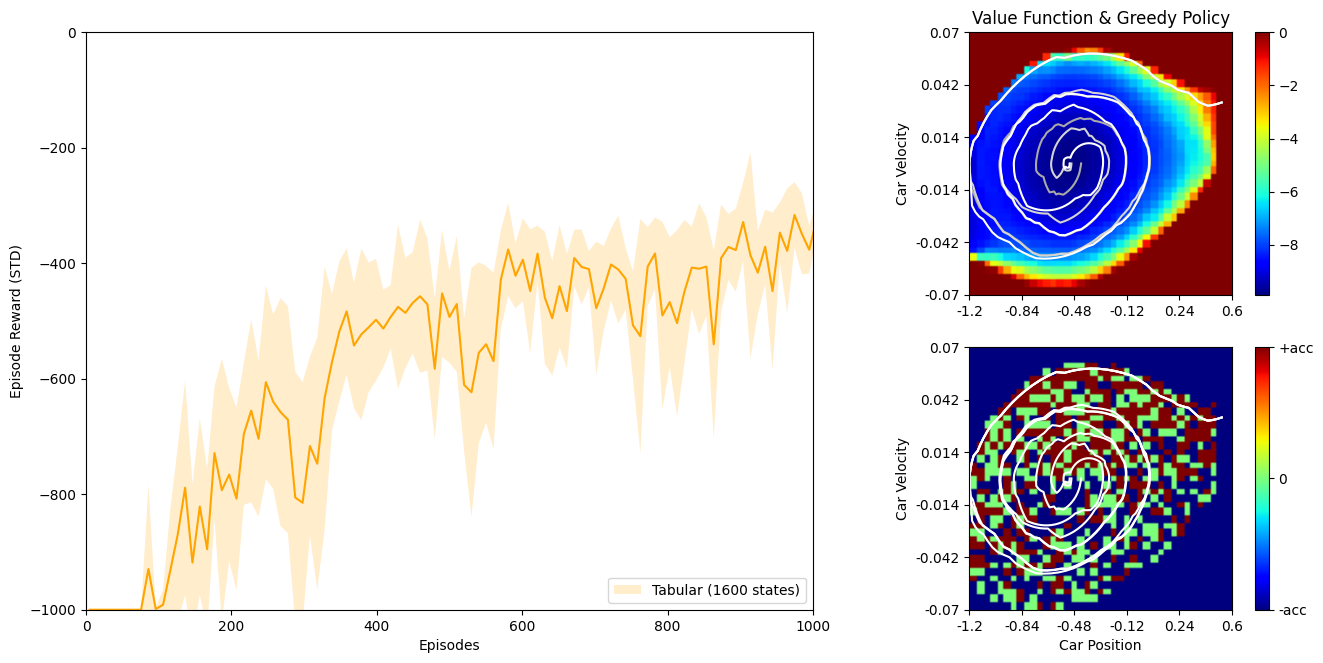

In [6]:
run_experiment(env, TabularQLearner(env, 40))
plot_all_results(env)

Discuss the resulting performance, value function and policy with your neighbours. Do you see a consistent behaviour policy, and if not, why?

# EXERCISE 2: Approximate Q-learning
In this exercise you will implement a QLearner based on gradient descend with a linear Q-value function.


## TASK 2a: basis functions
Now we want to use approximate Q-learning for linear functions. Familiarize yourself with our specification of basis functions.

In [7]:
class BasisFunctions:
    """ Abstract class that specifies basis functions. """
    name = None                  # the name of the basis function
    num_features = None          # the number of basis functions
    _env_low = None
    _env_high = None
    _env_dx = None

    def __init__(self, env):
        self._env_low = env.observation_space.low
        self._env_high = env.observation_space.high
        self._env_dx = self._env_high - self._env_low

    def __call__(self, state):
        """ Returns the basis function outputs of the given state as a vector.  """
        assert False, "Abstract class must be inherited from to call."

    def new_weights(self):
        """ Returns a newly initialized fitting weight vector. """
        return np.zeros(self.num_features)

class OneHot (BasisFunctions):
    """ one-hot encoding of 2d-spaces """
    n_states = None

    def __init__(self, env, n_states):
        """ Creates a one-hot encoding with n_states discrete intervals in each input dimension. """
        BasisFunctions.__init__(self, env)
        self.name = "OneHot"
        self.n_states = n_states
        self.num_features = n_states ** 2

    def __call__(self, state):
        """ Overrides the () operator and returns a one-hot encoding of the given state."""
        phi = np.zeros(self.num_features)
        index = np.floor((state - self._env_low) / self._env_dx * (self.n_states-1))
        phi[int(index[0] * self.n_states + index[1])] = 1
        return phi

class RBF (BasisFunctions):
    """ Exponential radial basis functions in 2d spaces."""
    normalize = True      # this flag normalizes the L_1 norm of the output vector to 1
    centers = None
    sigmas = None

    def __init__(self, env, n_bases):
        """ Creates a set of equidistant basis functions with n_bases functions in each input dimension. """
        BasisFunctions.__init__(self, env)
        self.name = "RBF"
        self.num_features = n_bases ** 2
        self._make_centers(n_bases)
    
    def _make_centers(self, n_bases):
        """ Initializes the centers of the RBF basis functions as an equidistant grid 
            and width sigma as the distance between the centers to guarantee enough overlap. """
        # Create centers of the RBF
        self.centers = np.zeros((2, n_bases ** 2))
        self.centers[0, :] = np.repeat(np.linspace(self._env_low[0], self._env_high[0], num=n_bases), n_bases)
        self.centers[1, :] = np.tile(np.linspace(self._env_low[1], self._env_high[1], num=n_bases), n_bases)
        # Create widths of the RBF
        self.sigmas = np.zeros((2, n_bases ** 2))
        self.sigmas[0, :] = np.repeat(np.ones(n_bases) * self._env_dx[0] / (n_bases-1), n_bases)
        self.sigmas[1, :] = np.tile(np.ones(n_bases)  * self._env_dx[1] / (n_bases-1), n_bases)

    def __call__(self, state):
        """ Overrides the () operator and returns the (normalised) RBF output for the given state."""
        # Compute the RBFs
        phi = np.exp(- np.sum(((self.centers - np.expand_dims(state, axis=1)) / self.sigmas) ** 2, axis=0))
        # Optionally normalize the RBF output to sum 1
        if self.normalize:
            phi /= np.sum(phi, axis=0)
        # Return feature(s)
        return phi

## Task 2b: semi-gradients 
Derive the semi-gradient of the quadratic Bellman-error of Q-learning at time $t$ (i.e. after observing s_t, a_t, r_t and s_{t+1}) for a linear Q-function. Write down both the loss function and the semi-gradient as a LaTeX formula:

The Q-value function is given by
$$
Q(s,a) = \vec{w}^{\,a} \cdot \vec{\phi}(s)
$$

\begin{align*}
    \mathcal{L}_t &= \frac{1}{2}\!\left(r_t + \gamma \max_{a'} \vec{w}^{\,a'} \cdot \vec{\phi}(s_{t+1}) - \vec{w}^{\,a_t} \cdot \vec{\phi}(s_t)\right)^2 \\[4mm]
    \frac{\partial \mathcal{L}_t}{\partial \vec{w}^{\,a_t}} &= -\underbrace{\left(r_t + \gamma \max_{a'} \vec{w}^{\,a'} \cdot \vec{\phi}(s_{t+1}) - \vec{w}^{\,a_t} \cdot \vec{\phi}(s_t)\right)}_{\delta_t\;\text{(TD-error)}} \cdot \vec{\phi}(s_t)
\end{align*}

The **semi**-gradient update therefore is:
$$
\vec{w}^{\,a_t} \;\leftarrow\; \vec{w}^{\,a_t} + \alpha\,\delta_t\,\vec{\phi}(s_t)
$$

It is *semi*-gradient because the bootstrap target $r_t + \gamma\max_{a'}Q(s_{t+1},a')$ is treated as a constant when differentiating — we do not back-propagate through it.


## TASK 2c: linear Q-functions 
Implement the corresponding semi-gradient QLearner in the below skeleton. Make sure that, similarly to task 1a, the end of the episode (done=True) is handled correctly.

In [8]:
class LinearQLearner (QLearner):
    learn_rate = 0.1
    basis = None
    weights = None  # shape (n_actions, num_features)

    def __init__(self, env, basis: BasisFunctions):
        self.name = "Linear (%u %s)" % (basis.num_features, basis.name)
        self.basis = basis
        n_actions = env.action_space.n
        # One weight vector per action, zero-initialised
        self.weights = np.zeros((n_actions, basis.num_features))

    def q_values(self, state):
        ''' Returns Q(s,a) for all actions as a np.ndarray. '''
        phi = self.basis(state)        # feature vector phi(s), shape (num_features,)
        return self.weights @ phi      # shape (n_actions,)

    def sample(self, state):
        ''' Greedy action w.r.t. current Q-values. '''
        return np.argmax(self.q_values(state))

    def update(self, state, action, reward, next_state, done):
        ''' Semi-gradient Q-learning update. '''
        phi      = self.basis(state)
        phi_next = self.basis(next_state)

        # Bootstrap target (no future value at terminal step)
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.weights @ phi_next)

        # TD-error
        td_error = target - self.weights[action] @ phi

        # Semi-gradient update: w^a <- w^a + alpha * delta * phi(s)
        self.weights[action] += self.learn_rate * td_error * phi


## TASK 2d: approximation with one-hot bases 
Test your above implementation with one-hot basis functions (with 40 bases in each state-dimension). 

----- Start Learning with Linear (1600 OneHot) Q-learning -----
Episode #50 (50000 steps) -- Total reward = -1000, epsilon=0.1.
Episode #150 (144272 steps) -- Total reward = -606, epsilon=0.1.
Episode #250 (219001 steps) -- Total reward = -672, epsilon=0.1.
Episode #350 (286761 steps) -- Total reward = -490, epsilon=0.1.
Episode #450 (336702 steps) -- Total reward = -411, epsilon=0.1.
Episode #550 (389266 steps) -- Total reward = -370, epsilon=0.1.
Episode #650 (433427 steps) -- Total reward = -671, epsilon=0.1.
Episode #750 (477029 steps) -- Total reward = -472, epsilon=0.1.
Episode #850 (521521 steps) -- Total reward = -356, epsilon=0.1.
Episode #950 (561307 steps) -- Total reward = -393, epsilon=0.1.


C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["%g" % (env_low[1] + i * (env_high[1] - env_low[1]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py

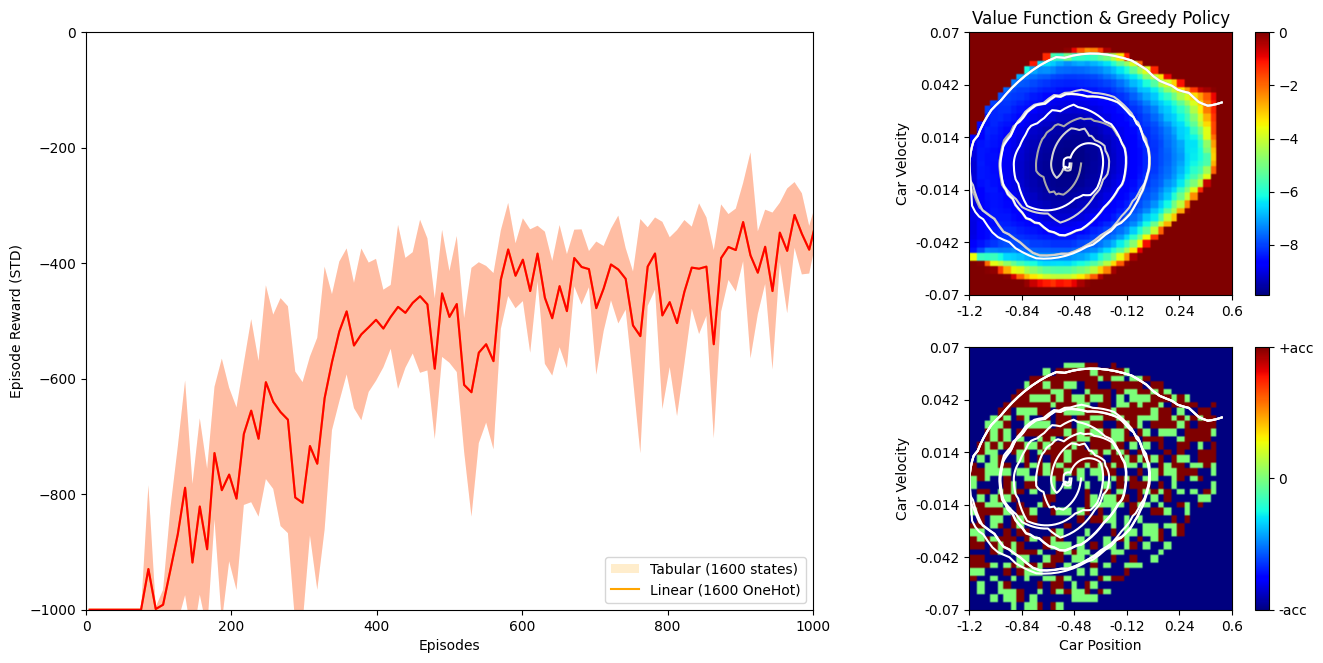

In [9]:
run_experiment(env, LinearQLearner(env, OneHot(env, 40)))
plot_all_results(env)

Can you compare your results with the TabularQLearner? What's your conclusion and why?

## Task 2e: approximation with RBF bases
Now test your LinearQLearner with the given RBF bases (15 centers for each state dimension). 

----- Start Learning with Linear (256 RBF) Q-learning -----
Episode #50 (44509 steps) -- Total reward = -627, epsilon=0.1.
Episode #150 (84187 steps) -- Total reward = -351, epsilon=0.1.
Episode #250 (110867 steps) -- Total reward = -353, epsilon=0.1.
Episode #350 (138880 steps) -- Total reward = -195, epsilon=0.1.
Episode #450 (186520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #550 (286520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #650 (386520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #750 (486520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #850 (586520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #950 (686520 steps) -- Total reward = -1000, epsilon=0.1.


C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["%g" % (env_low[1] + i * (env_high[1] - env_low[1]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py

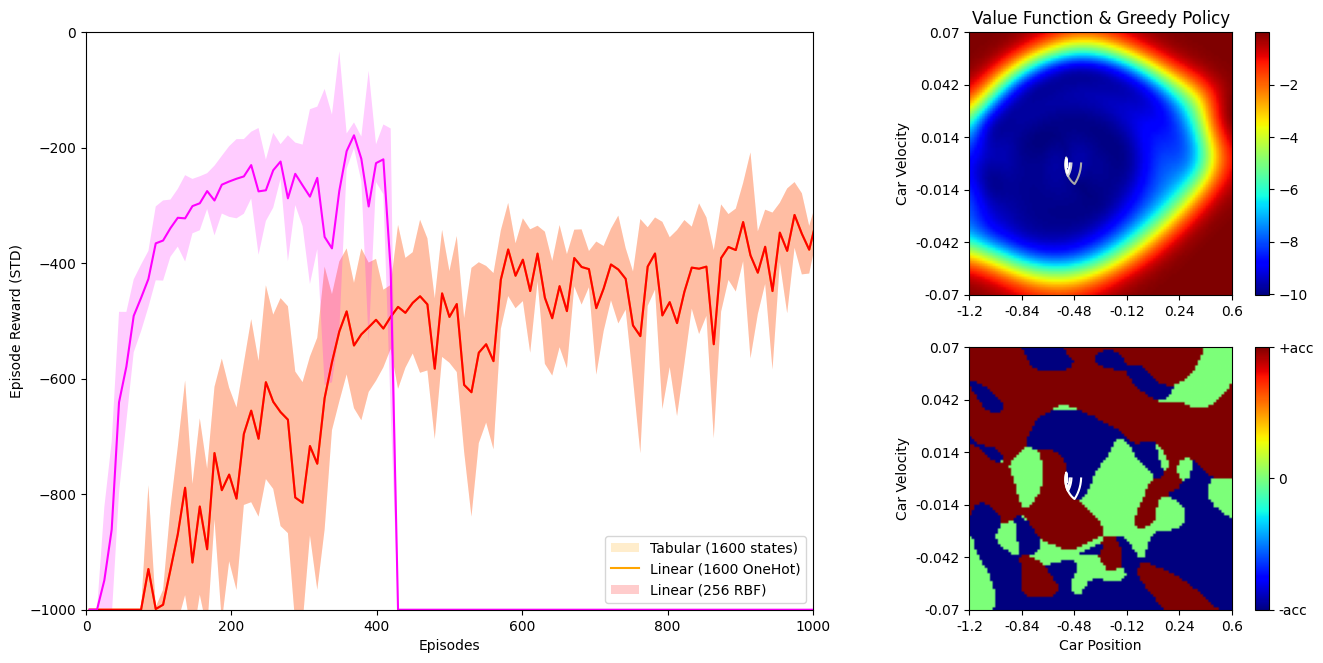

In [10]:
run_experiment(env, LinearQLearner(env, RBF(env, 16)))
plot_all_results(env)

Function approximation allows the agent to learn much faster, but the agent's performance can become extremly unstable in later episodes. This is somewhat surprising, as the lecture has established that semi-gradient TD(0) learning is supposed to converge in the linear case. Discuss with your neighbors why this is not the case here. If you want, change the number of episodes in run_experiment() to a value at which your algorithm is still stable and compare the resulting values/policies.

# EXERCISE 3: Stabilising Approximate Q-learning
Q-learning with semi-gradient descent is often unstable. In this exercise you will implement techniques that have emerged to stabilise approximate RL, namely Target Networks and Experience Replay Buffers.

## Task 3a: target networks
In this exercise you will improve the stability of gradient descend by using target networks. Note that for our purposes, the term "target network" refers to another weight vector. Extend the LinearQLearner with a target network, which is periodically updated with the current weights every 100 gradient steps.

In [11]:
class TargetQLearner (LinearQLearner):
    target_weights = None   # frozen copy used in bootstrap target
    update_freq    = 100    # sync target <- current every N gradient steps
    _step_count    = 0

    def __init__(self, env, basis):
        LinearQLearner.__init__(self, env, basis)
        self.name = "Target (%u %s)" % (basis.num_features, basis.name)
        self.target_weights = self.weights.copy()

    def update(self, state, action, reward, next_state, done):
        phi      = self.basis(state)
        phi_next = self.basis(next_state)

        # Use FROZEN target_weights for the bootstrap target
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.target_weights @ phi_next)

        td_error = target - self.weights[action] @ phi
        self.weights[action] += self.learn_rate * td_error * phi

        # Periodic target-network refresh
        self._step_count += 1
        if self._step_count % self.update_freq == 0:
            self.target_weights = self.weights.copy()


Now test your above TargetQLearner with the same 16x16 RBF bases as above.

----- Start Learning with Target (256 RBF) Q-learning -----
Episode #50 (44398 steps) -- Total reward = -433, epsilon=0.1.
Episode #150 (84325 steps) -- Total reward = -405, epsilon=0.1.
Episode #250 (108434 steps) -- Total reward = -316, epsilon=0.1.
Episode #350 (126882 steps) -- Total reward = -162, epsilon=0.1.
Episode #450 (144332 steps) -- Total reward = -158, epsilon=0.1.
Episode #550 (161679 steps) -- Total reward = -148, epsilon=0.1.
Episode #650 (179349 steps) -- Total reward = -146, epsilon=0.1.
Episode #750 (195949 steps) -- Total reward = -150, epsilon=0.1.
Episode #850 (213118 steps) -- Total reward = -293, epsilon=0.1.
Episode #950 (228619 steps) -- Total reward = -153, epsilon=0.1.


C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["%g" % (env_low[1] + i * (env_high[1] - env_low[1]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py

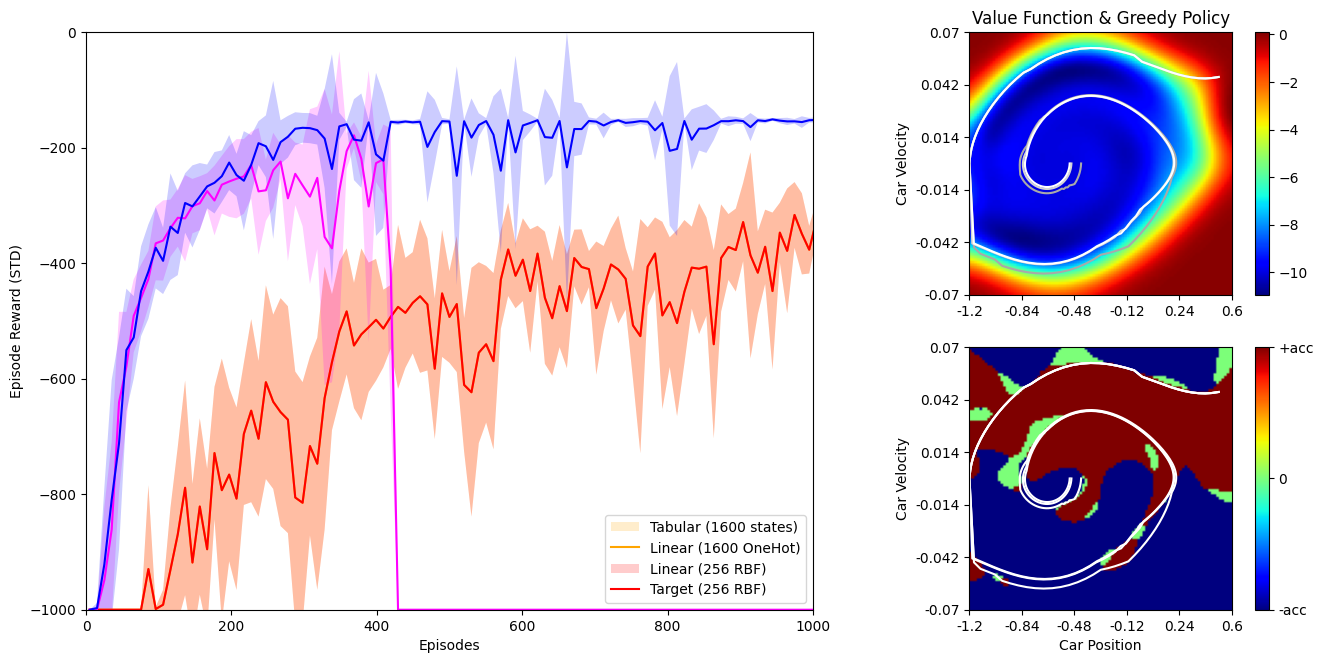

In [12]:
run_experiment(env, TargetQLearner(env, RBF(env, 16)))
plot_all_results(env)

The target networks can stabilise an agent's performance quite a bit, but do not have to. Do you observe more stable learning? Is the behaviour still unstable at the end?

## TASK 3b: double Q-learning
Extend the class TargetQLearner to implement double Q-learning (akin to Double DQN from the lecture). Double Q-learning determines the best action for the next state s_{t+1} using the current network, but evaluates that action on the target network, just as in TargetQLearner. 

In [13]:
class DoubleQLearner (TargetQLearner):

    def __init__(self, env, basis):
        TargetQLearner.__init__(self, env, basis)
        self.name = "Double (%u %s)" % (basis.num_features, basis.name)

    def update(self, state, action, reward, next_state, done):
        ''' Double Q-learning:
            - Select best next action using CURRENT weights
            - Evaluate that action using TARGET weights  (decouples selection from evaluation)
        '''
        phi      = self.basis(state)
        phi_next = self.basis(next_state)

        if done:
            target = reward
        else:
            best_next_action = np.argmax(self.weights @ phi_next)       # current net selects
            target = reward + self.gamma * (self.target_weights[best_next_action] @ phi_next)  # target net evaluates

        td_error = target - self.weights[action] @ phi
        self.weights[action] += self.learn_rate * td_error * phi

        self._step_count += 1
        if self._step_count % self.update_freq == 0:
            self.target_weights = self.weights.copy()


Now test your above DoubleQLearner with the same RBF bases as above. Double Q-learning should further stabilise the agent's performance. 

----- Start Learning with Double (256 RBF) Q-learning -----
Episode #50 (43784 steps) -- Total reward = -555, epsilon=0.1.
Episode #150 (84573 steps) -- Total reward = -279, epsilon=0.1.
Episode #250 (112032 steps) -- Total reward = -185, epsilon=0.1.
Episode #350 (137944 steps) -- Total reward = -256, epsilon=0.1.
Episode #450 (162582 steps) -- Total reward = -180, epsilon=0.1.
Episode #550 (187949 steps) -- Total reward = -307, epsilon=0.1.
Episode #650 (233837 steps) -- Total reward = -1000, epsilon=0.1.
Episode #750 (333837 steps) -- Total reward = -1000, epsilon=0.1.
Episode #850 (433837 steps) -- Total reward = -1000, epsilon=0.1.
Episode #950 (533837 steps) -- Total reward = -1000, epsilon=0.1.


C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["%g" % (env_low[1] + i * (env_high[1] - env_low[1]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py

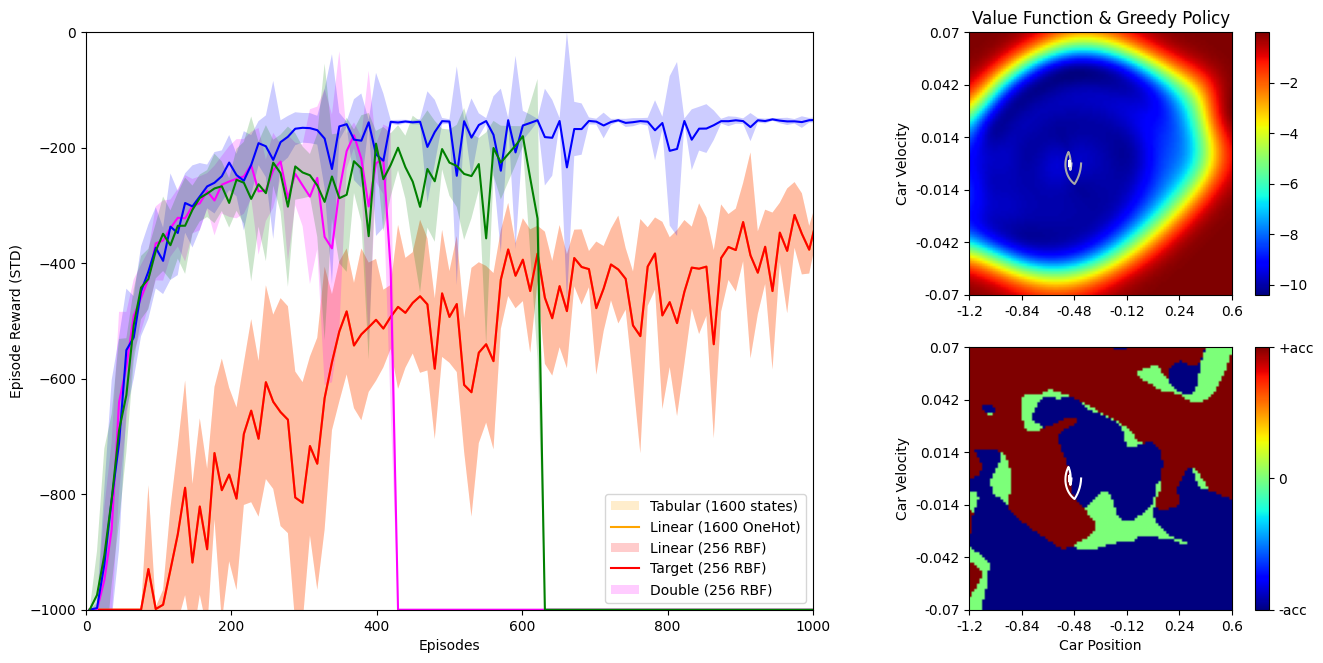

In [14]:
run_experiment(env, DoubleQLearner(env, RBF(env, 16)))
plot_all_results(env)

If you do not have a stable solution by now, increase the number of basis fuctions for each state dimension.
How does the policy look like in comparison to the tabular case in task 1c? Can you formulate an optimal policy for mountain-car based on your observations?

# EXERCISE 4: Deep Q-Networks
In this exercise we will implement Q-learning with a neural network. Read the DQN paper by Mnih et al. https://www.cs.toronto.edu/~vmnih/docs/dqn.pdf for help with the exercise.

## TASK 4a
Implement a deep Q net that holds 10,000 transitions and uses a mini-batch of 32 samples. Make sure that the mini-batch always includes the newest transition.

The following code describes a simple replay buffer which is used to store (state, action, reward, next_state, done) tuples.

In [15]:
class Replay_buffer():
    def __init__(self, capacity):
        self.buffer = []
        for i in range(capacity):
                self.buffer.append(None)
        self.capacity = capacity
        self.insert_index = 0
        self.num_exp = 0

    def push(self, sarst):
        self.buffer[self.insert_index] = sarst
        self.insert_index = (self.insert_index + 1)%self.capacity
        if self.num_exp < self.capacity:
            self.num_exp += 1

    def sample_buffer(self):
        index = random.randint(0, self.num_exp-1)
        return self.buffer[index]

    def sample_batch(self, size):
        batch = []
        for i in range(size):
            batch.append(self.sample_buffer())
        return batch

Similarly the code-let below describes simple a 3 layer neural network which outputs an action value for all the valid actions in mountaincar.

In [16]:
class Value_Net(torch.nn.Module):
    hidden = 20 
    
    def __init__(self):
        super(Value_Net, self).__init__()
        self.fc1 = torch.nn.Linear(2, self.hidden)
        self.fc2 = torch.nn.Linear(self.hidden, self.hidden)
        self.fc3 = torch.nn.Linear(self.hidden, 3)

    def forward(self, x):
        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.fc2(x))
        x = self.fc3(x)
        return x

Complete the class DQLearner to implement a DQN that solves the mountain car environment.

In [17]:
class DQLearner(QLearner):
    buffer_size        = 10000
    batch_size         = 32
    learning_rate      = 1e-3
    target_update_freq = 100   # gradient steps between target-net syncs
    qnet               = None
    target_net         = None
    buffer             = None
    optimizer          = None
    criterion          = None
    _step_count        = 0

    def __init__(self):
        self.name       = "DQN"
        self.qnet       = Value_Net()
        self.target_net = Value_Net()
        self.target_net.load_state_dict(self.qnet.state_dict())
        self.target_net.eval()                        # target never updated by gradient
        self.buffer     = Replay_buffer(self.buffer_size)
        self.optimizer  = torch.optim.RMSprop(self.qnet.parameters(), lr=self.learning_rate)
        self.criterion  = torch.nn.MSELoss()

    def q_values(self, state):
        return self.qnet(torch.Tensor(state))

    def sample(self, state):
        return np.argmax(self.q_values(state).detach().numpy())

    def update(self, state, action, reward, next_state, done):
        # Store latest transition
        obs = {'old': state, 'action': action, 'reward': reward,
               'new': next_state, 'done': done}
        self.buffer.push(obs)
        if self.buffer.num_exp < self.batch_size:
            return

        # Sample mini-batch and always include the newest transition
        batch = self.buffer.sample_batch(self.batch_size - 1)
        batch.append(obs)

        # Build tensors
        states      = torch.Tensor(np.array([t['old']        for t in batch]))
        actions     = torch.LongTensor([t['action']          for t in batch])
        rewards     = torch.Tensor([t['reward']              for t in batch])
        next_states = torch.Tensor(np.array([t['new']        for t in batch]))
        dones       = torch.Tensor([float(t['done'])         for t in batch])

        # Q(s, a) for the actions that were taken
        current_q = self.qnet(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target: r + gamma * max_a' Q_target(s', a')   [0 on terminal]
        with torch.no_grad():
            next_q   = self.target_net(next_states).max(dim=1).values
            target_q = rewards + self.gamma * (1.0 - dones) * next_q

        # Compute loss, zero grads, backprop, step
        loss = self.criterion(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Sync target network periodically
        self._step_count += 1
        if self._step_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.qnet.state_dict())

    def set_epsilon(self, iter):
        ''' Exponentially decays the exploration parameter epsilon. '''
        self.epsilon = nate**(-iter / 250.0)


----- Start Learning with DQN Q-learning -----
Episode #50 (50000 steps) -- Total reward = -1000, epsilon=0.822012.
Episode #150 (150000 steps) -- Total reward = -1000, epsilon=0.551011.
Episode #250 (217290 steps) -- Total reward = -341, epsilon=0.369354.
Episode #350 (251769 steps) -- Total reward = -428, epsilon=0.247585.
Episode #450 (293727 steps) -- Total reward = -241, epsilon=0.165961.
Episode #550 (332634 steps) -- Total reward = -744, epsilon=0.111247.
Episode #650 (378965 steps) -- Total reward = -609, epsilon=0.0745713.
Episode #750 (402566 steps) -- Total reward = -194, epsilon=0.0499866.
Episode #850 (444827 steps) -- Total reward = -225, epsilon=0.033507.
Episode #950 (482567 steps) -- Total reward = -224, epsilon=0.0224604.


C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["%g" % (env_low[1] + i * (env_high[1] - env_low[1]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py

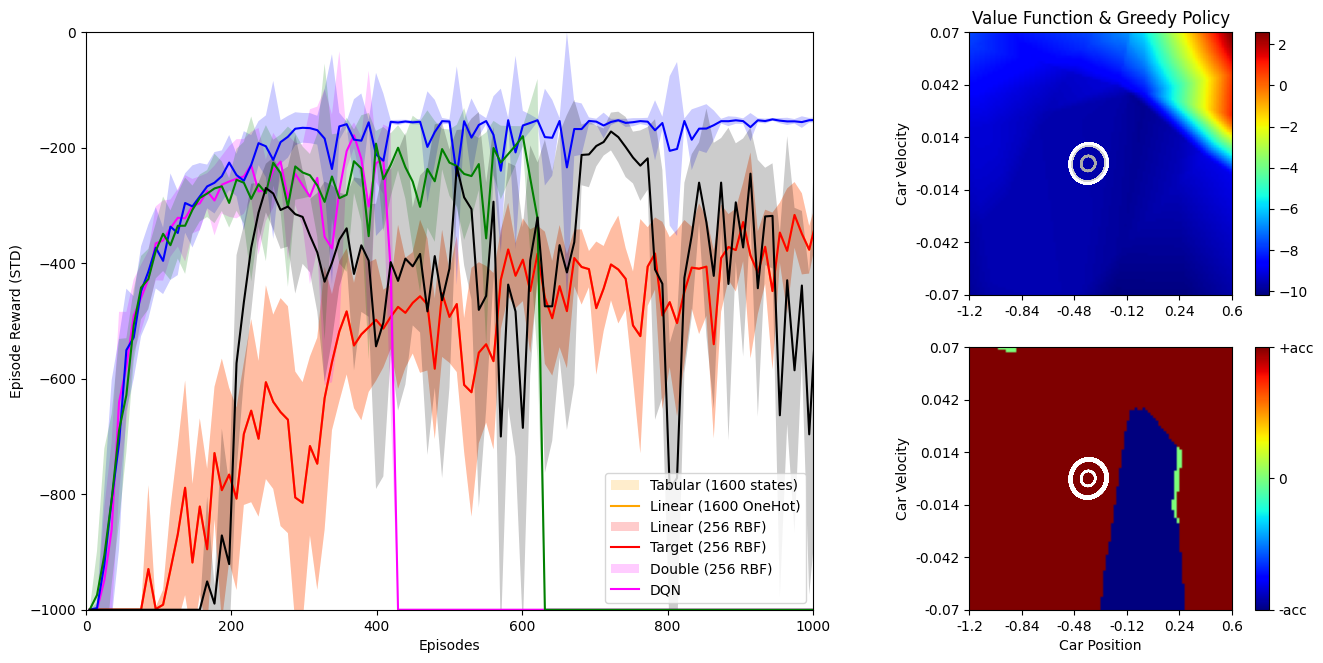

In [18]:
run_experiment(env, DQLearner())
plot_all_results(env)

## TASK 4b: DQN variations
There are several things that can be tried out with the DQN. Figure out if using different learning rates, losses and network architecture (number of layers and connectivity) changes the network performance. You can even change the replay buffer implementation to define some heuristic to draw samples from. Explore if these modifications help.

# EXERCISE 5: Improve Q-learning
If you have finished the above tasks and still have some time left, play aound with your solutions to improve performance. In particular, test the following changes for any of the above classes that inherit from LinearQLearner:

## TASK 5a: number of basis function
Plot the performance of the LinearQLearner (and it's descendants) against the number of used RBF basis functions in [10x10, ..., 20x20]. Does an increasing number of bases increase or decrease stability? Note that you need to write your own plotting script.

----- Start Learning with Linear (100 RBF) Q-learning -----
Episode #50 (33947 steps) -- Total reward = -366, epsilon=0.1.
Episode #150 (81865 steps) -- Total reward = -1000, epsilon=0.1.
Episode #250 (171600 steps) -- Total reward = -1000, epsilon=0.1.
Episode #350 (271600 steps) -- Total reward = -1000, epsilon=0.1.
Episode #450 (371600 steps) -- Total reward = -1000, epsilon=0.1.
Episode #550 (471600 steps) -- Total reward = -1000, epsilon=0.1.
Episode #650 (571600 steps) -- Total reward = -1000, epsilon=0.1.
Episode #750 (671600 steps) -- Total reward = -1000, epsilon=0.1.
Episode #850 (771600 steps) -- Total reward = -1000, epsilon=0.1.
Episode #950 (871600 steps) -- Total reward = -1000, epsilon=0.1.
  Finished 10x10
----- Start Learning with Linear (144 RBF) Q-learning -----
Episode #50 (37130 steps) -- Total reward = -479, epsilon=0.1.
Episode #150 (74593 steps) -- Total reward = -120, epsilon=0.1.
Episode #250 (153510 steps) -- Total reward = -1000, epsilon=0.1.
Episode #350 (

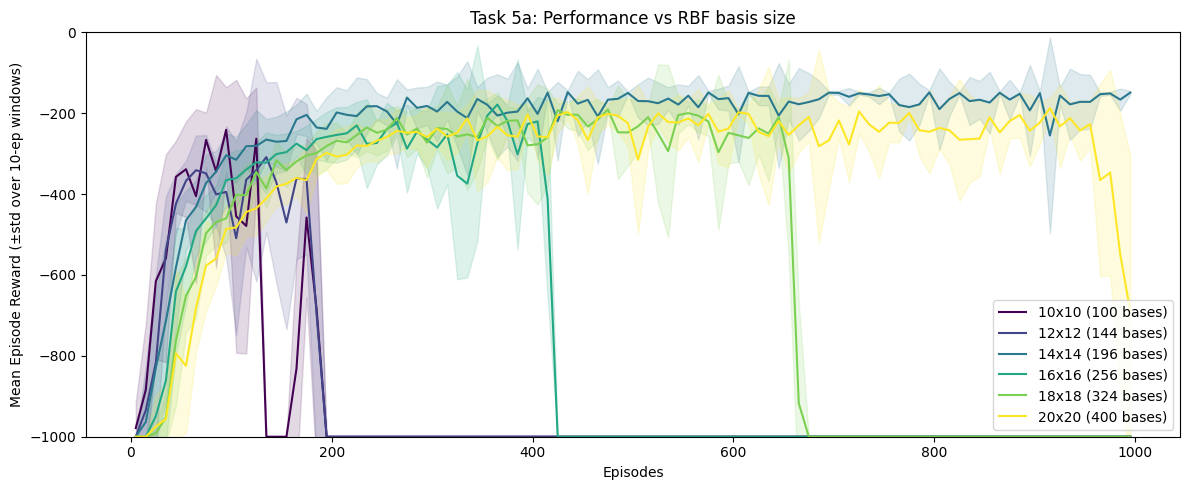

More bases improve early performance but increase late-training instability,
because larger weight vectors amplify target non-stationarity in Q-learning.


In [19]:
# TASK 5a: LinearQLearner performance vs number of RBF basis functions
import matplotlib.pyplot as plt

basis_sizes  = [10, 12, 14, 16, 18, 20]
results_5a   = {}

for n in basis_sizes:
    clear_plots()
    run_experiment(env, LinearQLearner(env, RBF(env, n)))
    results_5a[n] = list(plot_rewards[0])
    print(f"  Finished {n}x{n}")

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(basis_sizes)))
for color, n in zip(colors, basis_sizes):
    rew = np.array(results_5a[n])
    rew = rew[:len(rew) - len(rew) % 10].reshape(-1, 10)
    m   = rew.mean(axis=1)
    s   = rew.std(axis=1)
    x   = np.arange(5, len(m) * 10 + 5, 10)
    ax.fill_between(x, m - s, m + s, alpha=0.15, color=color)
    ax.plot(x, m, color=color, label=f'{n}x{n} ({n**2} bases)')

ax.set_xlabel('Episodes')
ax.set_ylabel('Mean Episode Reward (±std over 10-ep windows)')
ax.set_title('Task 5a: Performance vs RBF basis size')
ax.set_ylim(-1000, 0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("More bases improve early performance but increase late-training instability,")
print("because larger weight vectors amplify target non-stationarity in Q-learning.")


## TASK 5b: learning rate
Change the implementation of LinearQLearner (and it's descendants) to decrease the learning rate slowly. How does this change affect learning rate and stability? 

----- Start Learning with Linear (256 RBF) Q-learning -----
Episode #50 (44509 steps) -- Total reward = -627, epsilon=0.1.
Episode #150 (84187 steps) -- Total reward = -351, epsilon=0.1.
Episode #250 (110867 steps) -- Total reward = -353, epsilon=0.1.
Episode #350 (138880 steps) -- Total reward = -195, epsilon=0.1.
Episode #450 (186520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #550 (286520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #650 (386520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #750 (486520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #850 (586520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #950 (686520 steps) -- Total reward = -1000, epsilon=0.1.
----- Start Learning with DecayLR (256 RBF) Q-learning -----
Episode #50 (48490 steps) -- Total reward = -1000, epsilon=0.1.
Episode #150 (140830 steps) -- Total reward = -837, epsilon=0.1.
Episode #250 (231101 steps) -- Total reward = -980, epsilon=0.1.
Episode #350 (318869 steps) -- T

C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["%g" % (env_low[1] + i * (env_high[1] - env_low[1]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py

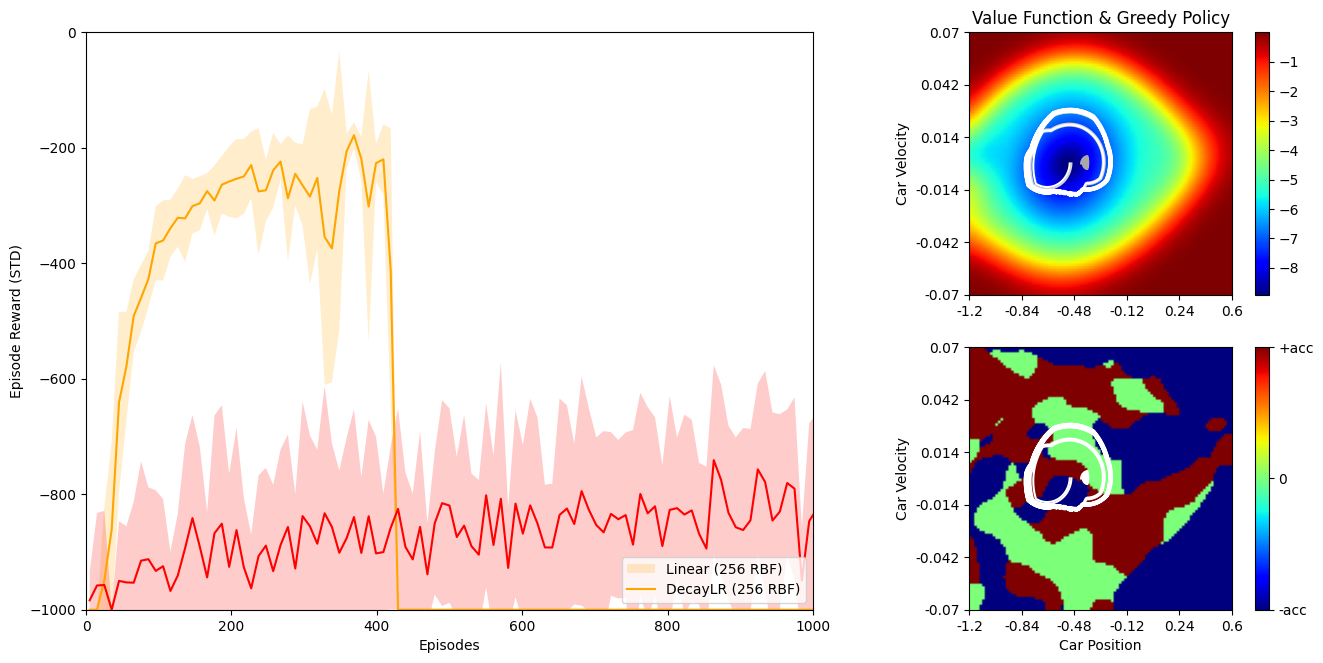

Decaying alpha stabilises later training: once good Q-values are learned,
smaller updates prevent noisy targets from overwriting them.


In [20]:
# TASK 5b: Decaying learning rate
class DecayLRQLearner(LinearQLearner):
    '''LinearQLearner with alpha_t = alpha_0 / (1 + k * t).'''
    lr_init  = 0.5
    lr_decay = 0.001
    _t       = 0

    def __init__(self, env, basis):
        super().__init__(env, basis)
        self.name       = "DecayLR (%u %s)" % (basis.num_features, basis.name)
        self.learn_rate = self.lr_init

    def update(self, state, action, reward, next_state, done):
        self._t        += 1
        self.learn_rate = self.lr_init / (1.0 + self.lr_decay * self._t)
        super().update(state, action, reward, next_state, done)

clear_plots()
run_experiment(env, LinearQLearner(env,   RBF(env, 16)))   # baseline constant LR
run_experiment(env, DecayLRQLearner(env,  RBF(env, 16)))   # decaying LR
plot_all_results(env)

print("Decaying alpha stabilises later training: once good Q-values are learned,")
print("smaller updates prevent noisy targets from overwriting them.")


## TASK 5c: exploration
The experiment defined in task 1b uses epsilon-greedy exploration with a constant epsilon=0.1. Override the set_epsilon method of (a subclass of) LinearQLearner to implement a decay shedule, which decreases epsilon linearly from 1 to 0.01 in {10, 50, 100, 500} epsiodes. Does this improve the performance or not? What happens with an exponential decay schedule as in DQLearner?

----- Start Learning with Linear (256 RBF) Q-learning -----
Episode #50 (44509 steps) -- Total reward = -627, epsilon=0.1.
Episode #150 (84187 steps) -- Total reward = -351, epsilon=0.1.
Episode #250 (110867 steps) -- Total reward = -353, epsilon=0.1.
Episode #350 (138880 steps) -- Total reward = -195, epsilon=0.1.
Episode #450 (186520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #550 (286520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #650 (386520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #750 (486520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #850 (586520 steps) -- Total reward = -1000, epsilon=0.1.
Episode #950 (686520 steps) -- Total reward = -1000, epsilon=0.1.
----- Start Learning with LinearDecay(e=100) (256 RBF) Q-learning -----
Episode #50 (45544 steps) -- Total reward = -491, epsilon=0.5149.
Episode #150 (85512 steps) -- Total reward = -289, epsilon=0.01.
Episode #250 (117172 steps) -- Total reward = -190, epsilon=0.01.
Episode #350 (1462

C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["%g" % (env_low[1] + i * (env_high[1] - env_low[1]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py

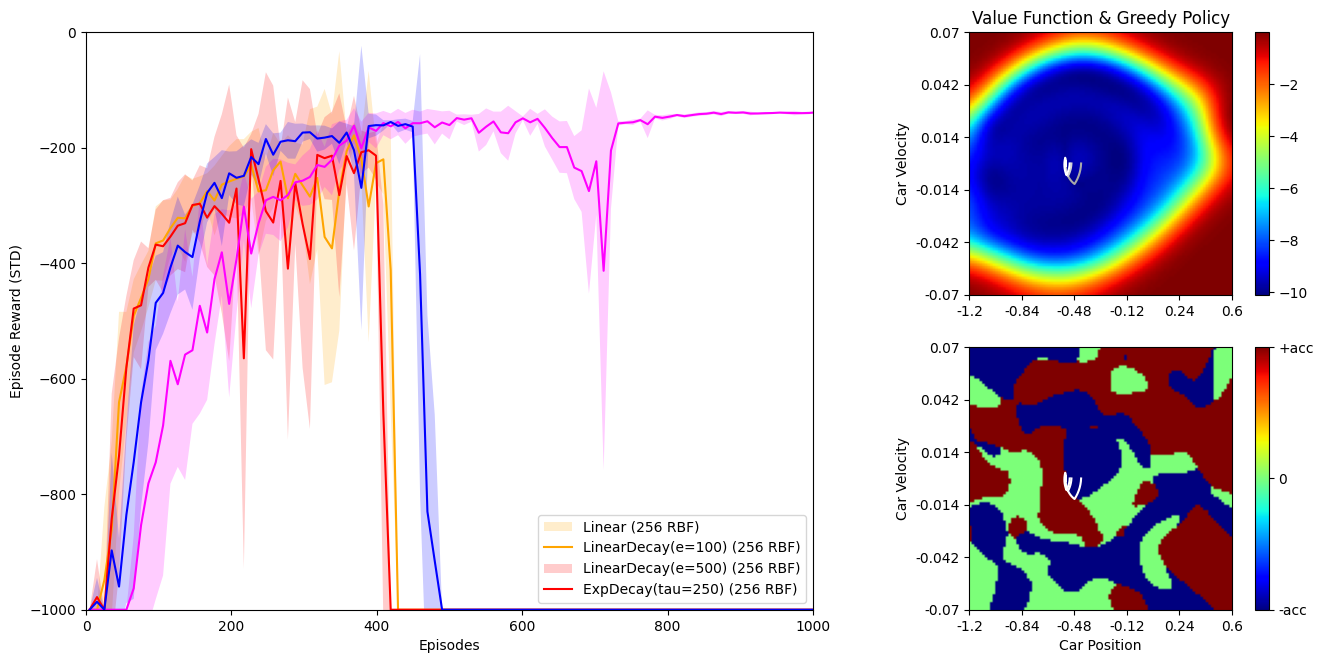

Fast decay (100 ep): explores quickly then exploits — good if near-optimal
  policy is discoverable early, risky if the initial policy is poor.
Slow decay (500 ep): maintains exploration longer, usually more stable.
Exp decay: smooth, asymptotes to 0 — similar to DQN schedule; often best.


In [21]:
# TASK 5c: Epsilon decay schedules
class LinearDecayQLearner(LinearQLearner):
    '''Linear epsilon decay from 1.0 to 0.01 over decay_episodes episodes.'''
    def __init__(self, env, basis, decay_episodes=100):
        super().__init__(env, basis)
        self.decay_eps = decay_episodes
        self.epsilon   = 1.0
        self.name = "LinearDecay(e=%d) (%u %s)" % (decay_episodes, basis.num_features, basis.name)

    def set_epsilon(self, iter):
        frac         = min(iter / self.decay_eps, 1.0)
        self.epsilon = 1.0 + frac * (0.01 - 1.0)


class ExpDecayQLearner(LinearQLearner):
    '''Exponential epsilon decay: eps = exp(-iter / tau).'''
    def __init__(self, env, basis, tau=250):
        super().__init__(env, basis)
        self.tau  = tau
        self.name = "ExpDecay(tau=%d) (%u %s)" % (tau, basis.num_features, basis.name)

    def set_epsilon(self, iter):
        self.epsilon = nate ** (-iter / self.tau)


clear_plots()
run_experiment(env, LinearQLearner(env,       RBF(env, 16)))
run_experiment(env, LinearDecayQLearner(env,  RBF(env, 16), 100))
run_experiment(env, LinearDecayQLearner(env,  RBF(env, 16), 500))
run_experiment(env, ExpDecayQLearner(env,     RBF(env, 16), 250))
plot_all_results(env)

print("Fast decay (100 ep): explores quickly then exploits — good if near-optimal")
print("  policy is discoverable early, risky if the initial policy is poor.")
print("Slow decay (500 ep): maintains exploration longer, usually more stable.")
print("Exp decay: smooth, asymptotes to 0 — similar to DQN schedule; often best.")


## TASK 5d: DQN variations
There are several things that can be tried out with the DQN. Figure out if using different learning rates, losses and network architecture (number of layers and connectivity) changes the network performance. You can even change the replay buffer implementation to define some heuristic to draw samples from. Explore if these modifications help.

----- Start Learning with DQN Q-learning -----
Episode #50 (50000 steps) -- Total reward = -1000, epsilon=0.822012.
Episode #150 (149400 steps) -- Total reward = -1000, epsilon=0.551011.
Episode #250 (246196 steps) -- Total reward = -1000, epsilon=0.369354.
Episode #350 (308621 steps) -- Total reward = -337, epsilon=0.247585.
Episode #450 (336816 steps) -- Total reward = -258, epsilon=0.165961.
Episode #550 (390496 steps) -- Total reward = -250, epsilon=0.111247.
Episode #650 (425385 steps) -- Total reward = -699, epsilon=0.0745713.
Episode #750 (464973 steps) -- Total reward = -696, epsilon=0.0499866.
Episode #850 (511562 steps) -- Total reward = -323, epsilon=0.033507.
Episode #950 (549636 steps) -- Total reward = -468, epsilon=0.0224604.
----- Start Learning with DQN-Deep(Adam) Q-learning -----
Episode #50 (50000 steps) -- Total reward = -1000, epsilon=0.822012.
Episode #150 (150000 steps) -- Total reward = -1000, epsilon=0.551011.
Episode #250 (247538 steps) -- Total reward = -1000

C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["%g" % (env_low[1] + i * (env_high[1] - env_low[1]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["%g" % (env_low[0] + i * (env_high[0] - env_low[0]) / 5) for i in range(6)])
C:\Users\Prathap Selvakumar\AppData\Local\Temp\ipykernel_23456\1509883902.py

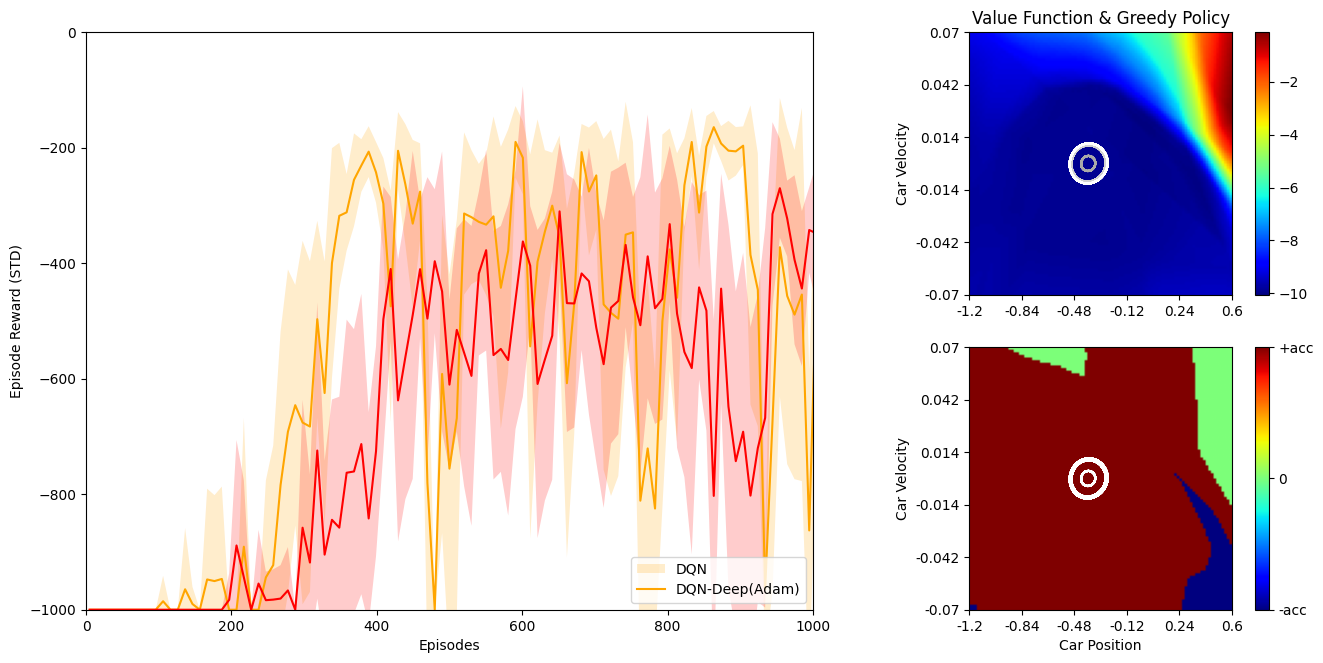

Deeper networks + Adam converge faster on MountainCar but can overfit noisy
replay samples. Tuning target_update_freq and batch_size matters most.


In [22]:
# TASK 5d: DQN architectural variants
class Value_Net_Deep(torch.nn.Module):
    '''Deeper network: 2 -> 64 -> 64 -> 64 -> 3 with ReLU activations.'''
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2,  64), torch.nn.ReLU(),
            torch.nn.Linear(64, 64), torch.nn.ReLU(),
            torch.nn.Linear(64, 64), torch.nn.ReLU(),
            torch.nn.Linear(64, 3),
        )
    def forward(self, x):
        return self.net(x)


class DQLearnerDeep(DQLearner):
    '''DQN with deeper net and Adam optimiser.'''
    learning_rate = 5e-4

    def __init__(self):
        super().__init__()
        self.name       = "DQN-Deep(Adam)"
        self.qnet       = Value_Net_Deep()
        self.target_net = Value_Net_Deep()
        self.target_net.load_state_dict(self.qnet.state_dict())
        self.target_net.eval()
        self.optimizer  = torch.optim.Adam(self.qnet.parameters(), lr=self.learning_rate)
        self.buffer     = Replay_buffer(self.buffer_size)
        self.criterion  = torch.nn.MSELoss()


clear_plots()
run_experiment(env, DQLearner())
run_experiment(env, DQLearnerDeep())
plot_all_results(env)

print("Deeper networks + Adam converge faster on MountainCar but can overfit noisy")
print("replay samples. Tuning target_update_freq and batch_size matters most.")


## TASK 5e: scientific evaluation
The experiment defined in task 1b fixes the random seed to ensure reproducability of results. However, each algorithm can behave very different depending on the seed. Run one (or all) above experiment(s) with 10 random seeds (i.e. comment out the lines that set the seed to 0) and plot the mean and staqndard deviation of the received rewards. Note that you may want to write your own plotting script, in which the shaded area refers to another type of standard deviation (between seeds, not over time) than in the given script.

In [ ]:
# TASK 5e: Scientific evaluation across multiple random seeds
import matplotlib.pyplot as plt

N_SEEDS = 10
N_EP    = 1000

agents_5e = {
    'Tabular 40x40':    lambda: TabularQLearner(env, 40),
    'Linear RBF 16x16': lambda: LinearQLearner(env, RBF(env, 16)),
    'Double RBF 16x16': lambda: DoubleQLearner(env, RBF(env, 16)),
}

def run_single(agent, seed):
    '''Run one episode loop without touching global plot state.'''
    state, _ = env.reset(seed=seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    rewards = []
    for ep in range(N_EP):
        state, _ = env.reset()
        total_r, done = 0, False
        while not done:
            s0 = state
            if np.random.uniform() < agent.get_epsilon():
                action = env.action_space.sample()
            else:
                action = agent.sample(s0)
            state, r, term, trunc, _ = env.step(action)
            done = term or trunc
            total_r += r
            agent.update(s0, action, r, state, done)
        agent.set_epsilon(ep)
        rewards.append(total_r)
    return rewards

all_rewards = {}
for name, make_agent in agents_5e.items():
    print(f"Evaluating '{name}' over {N_SEEDS} seeds ...")
    seed_results = [run_single(make_agent(), s) for s in range(N_SEEDS)]
    all_rewards[name] = seed_results

# Plot mean ± std ACROSS seeds
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['orange', 'blue', 'green']
for color, (name, seed_rewards) in zip(colors, all_rewards.items()):
    arr  = np.array(seed_rewards)                          # (N_SEEDS, N_EP)
    trim = arr.shape[1] - arr.shape[1] % 10
    arr  = arr[:, :trim].reshape(N_SEEDS, -1, 10).mean(axis=2)  # smooth over 10 ep
    m    = arr.mean(axis=0)
    s    = arr.std(axis=0)
    x    = np.arange(5, arr.shape[1] * 10 + 5, 10)
    ax.fill_between(x, m - s, m + s, alpha=0.2, color=color)
    ax.plot(x, m, color=color, label=name)

ax.set_xlabel('Episodes')
ax.set_ylabel('Mean Episode Reward ± Std (across seeds)')
ax.set_title('Task 5e: Reproducibility — mean and std across 10 random seeds')
ax.set_ylim(-1000, 0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("Shaded region = variability BETWEEN seeds (algorithmic variance).")
print("A narrow band indicates a robust algorithm; a wide band indicates")
print("strong sensitivity to initialisation / random exploration.")


Evaluating 'Tabular 40x40' over 10 seeds ...
Evaluating 'Linear RBF 16x16' over 10 seeds ...
